In [39]:
import bioframe as bf
import openpyxl
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt

In [40]:
DE_Lange_Spo11_file = pd.read_excel(r'/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/NIHMS819055-supplement-9_Spo11_de_Lange.xlsx', engine='openpyxl', skiprows=8)

/users/uladzis.khauratovich/.conda/envs/night/lib/python3.8/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [41]:
DE_Lange_Spo11 = DE_Lange_Spo11_file[
    DE_Lange_Spo11_file['chr'].str.contains('chr4_JH584292_random|chrUn_GL456370|chrUn_JH584304|chrUn_GL456389|chr4_GL456216_random|chrUn_GL456392') == False
    ].reset_index(drop=True)

In [43]:
# Sort by "Hits" descending and take top 1394 rows
DE_Lange_Spo11_cov_sorted = (
    DE_Lange_Spo11
    .sort_values(by="Hits", ascending=False)
    .reset_index(drop=True)
)

# Extract hottest hotspots
Spo11_hottest_hotspots = (
    DE_Lange_Spo11_cov_sorted
    .iloc[:1394][['chr', 'Start', 'End', 'center']]
    .rename(columns={'chr': 'chrom', 'Start': 'start', 'End': 'end'})
    .copy()
)

# Create hottest hotspots with ±1200 bp windows around center
Spo11_hottest_hotspots = (
    Spo11_hottest_hotspots
    .assign(
        start_win12=lambda df: df['center'] - 600,
        end_win12=lambda df: df['center'] + 600,
        start_win1=lambda df: df['center'] - 1000,
        end_win1=lambda df: df['center'] + 1000,
        start_win24=lambda df: df['center'] - 1200,
        end_win24=lambda df: df['center'] + 1200,
        chrom=lambda df: df['chrom'].str.replace(r'chr', '', regex=True)
    )
)

In [45]:
# for saving pdfs
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [46]:
bigWig_control_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [47]:
annot_gtf_tss = (
    pd.read_csv("/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Mus_musculus_GTF_genes_short_GRCm38_95.csv")
    # Compute TSS depending on strand, then expand ±600 bp
    .assign(
        start=lambda df: np.where(df['strand'] == '+', df['start'], df['end']) - 600,
        end=lambda df: np.where(df['strand'] == '+', df['start'], df['end']) + 600,
        chrom=lambda df: df['chrom'].str.replace('chr', '', regex=True)
    )
    # Drop mitochondrial chromosome
    .query("chrom != 'MT'")
    # Sort by chromosome and position
    .sort_values(by=['chrom', 'start'])
    # Keep only relevant columns
    .loc[:, ['chrom', 'start', 'end']]
    .reset_index(drop=True)
)

In [48]:
Spo11_outside_TSS = bf.setdiff(Spo11_hottest_hotspots, annot_gtf_tss)
print(len(Spo11_outside_TSS))

1366


In [49]:
Spo11_outside_TSS_noSex = Spo11_outside_TSS[~Spo11_outside_TSS['chrom'].isin(['X', 'Y'])]
print(len(Spo11_outside_TSS_noSex))

1314


In [50]:
Spo11_outside_TSS_noSex[['chrom', 'start_win12', 'end_win12']].to_csv(
    "/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/Spo11_hottest_noTSS_noSex_24kb.bed",
    sep="\t",
    header=False,  
    index=False
)

In [51]:
df = Spo11_outside_TSS_noSex

t_cov_Spo11_top_ctr = bigWig_control_consensus.stackup(df["chrom"],
                                                     df["start_win24"],
                                                     df["end_win24"],
                                                     bins=240, summary='sum')

t_cov_Spo11_top_exp = bigWig_exp_consensus.stackup(df["chrom"],
                                                     df["start_win24"],
                                                     df["end_win24"],
                                                     bins=240, summary='sum')

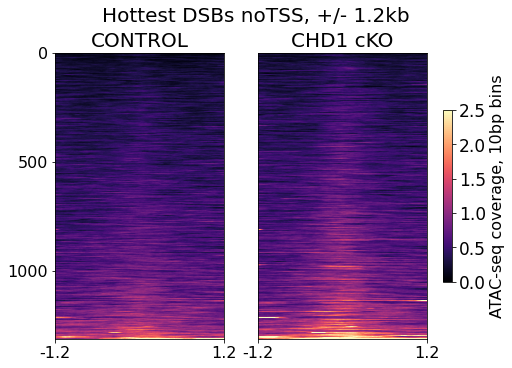

In [54]:
n_genes = t_cov_Spo11_top_ctr.shape[0]

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(7,5),
    gridspec_kw={'wspace': 0.002},  # reduce space between subplots
    constrained_layout=True
)

fig.suptitle('Hottest DSBs noTSS, +/- 1.2kb', fontsize=20)

order1 = np.argsort(np.sum(t_cov_Spo11_top_ctr[:, 0:240], axis=1))

# CONTROL plot (ax1)
ax1.set_title('CONTROL', fontsize=20)
im1 = ax1.imshow(t_cov_Spo11_top_ctr[order1], cmap="magma", aspect="auto", vmax=2.5, vmin=0)
ax1.set_xticks([0, 240], [-1.2, +1.2])
ax1.tick_params(axis='x', labelsize=16)
ax1.tick_params(axis='y', labelsize=16)

ax1.set_yticks(np.arange(0, n_genes, 500))
ax1.set_yticklabels(np.arange(0, n_genes, 500), fontsize=16)

# Add colorbar to ax1
cbar = fig.colorbar(im1, ax=ax2, shrink=0.6, pad=0.02, location='right')
cbar.set_label("ATAC-seq coverage, 10bp bins", fontsize=16)
cbar.ax.tick_params(labelsize=17)

# CHD1 cKO plot (ax2)
ax2.set_title('CHD1 cKO', fontsize=20)
im2 = ax2.imshow(t_cov_Spo11_top_exp[order1], cmap="magma", aspect="auto", vmax=2.5, vmin=0)
ax2.set_xticks([0, 240], [-1.2, +1.2])
ax2.tick_params(axis='x', labelsize=16)
ax2.set_yticks([])

plt.show()

#plt.savefig("/users/uladzis.khauratovich/Stackup_all_hottest_DSBs_noTSS_magma.svg", dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Hottest DSBs noTSS noSex (n=1314)')

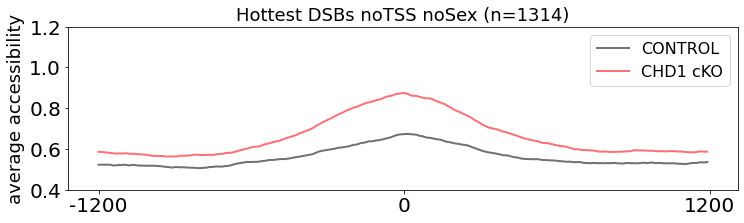

In [59]:
plt.figure(figsize=[12,3])

plt.ylim(0.4,1.2)
plt.xticks([0,120,240],[-1200,0,+1200])
plt.ylabel('average accessibility', fontsize=18)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)

# plt.plot(np.mean(cov_control_oriented_150[cov_exp_oriented_150.mean(axis=1) < np.quantile(cov_exp_oriented_150.mean(axis=1), 0.99)], axis=0), label='CONTROL', color='#717171', linewidth=2)
# plt.plot(np.mean(cov_exp_oriented_150[cov_exp_oriented_150.mean(axis=1) < np.quantile(cov_exp_oriented_150.mean(axis=1), 0.99)], axis=0), label='CHD1 cKO', color='#FC7077', linewidth=2)

plt.plot(np.mean(t_cov_Spo11_top_ctr, axis=0), label='CONTROL', color='#717171', linewidth=2)
plt.plot(np.mean(t_cov_Spo11_top_exp, axis=0), label='CHD1 cKO', color='#FC7077', linewidth=2)

plt.legend(fontsize=16)
#plt.legend(loc='lower right')

plt.title('Hottest DSBs noTSS noSex (n=1314)', fontsize=18)

#plt.savefig("/users/uladzis.khauratovich/Avr_coverage_hottest_DSBs_noTSS.svg", dpi=300, bbox_inches='tight')